## Resume Screening 

##  STEP 1 — Install Required Libraries

In [1]:
pip install pandas numpy scikit-learn nltk matplotlib seaborn wordcloud

Note: you may need to restart the kernel to use updated packages.


##  STEP 2 — Load and Explore the Dataset

In [5]:
import pandas as pd

# Load the dataset
df = pd.read_csv("resume_dataset.csv")

In [6]:
# See first 5 rows
print(df.head())


   resume_id candidate_name  \
0          1   Aarav Sharma   
1          2    Priya Mehta   
2          3     Ravi Kumar   
3          4    Sneha Patel   
4          5    Kiran Reddy   

                                         resume_text          job_category  \
0  Experienced Python developer with 5 years of e...          Data Science   
1  MBA graduate with 3 years of experience in mar...             Marketing   
2  Java backend developer with 7 years of experie...  Software Engineering   
3  Fresh graduate with B.Sc in Biology. Internshi...        Biology/Pharma   
4  Data analyst with 4 years of experience in SQL...          Data Science   

   experience_years     label  
0                 5  Selected  
1                 3  Rejected  
2                 7  Selected  
3                 0  Rejected  
4                 4  Selected  


In [7]:
# Check shape (rows, columns)
print("Shape:", df.shape)

Shape: (40, 6)


In [8]:
# Check label distribution
print(df['label'].value_counts())

label
Selected    20
Rejected    20
Name: count, dtype: int64


## STEP 3 — Text Preprocessing (The Heart of NLP)

In [9]:
import re
import nltk
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    # Step 1: Lowercase everything
    text = text.lower()
    
    # Step 2: Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Step 3: Tokenize (split into words)
    tokens = text.split()
    
    # Step 4: Remove stopwords (like 'the', 'is', 'in')
    tokens = [word for word in tokens if word not in stop_words]
    
    # Step 5: Stemming (reduce words to root: 'working' → 'work')
    tokens = [stemmer.stem(word) for word in tokens]
    
    # Join back to string
    return ' '.join(tokens)

# Apply preprocessing to all resumes
df['cleaned_text'] = df['resume_text'].apply(preprocess_text)

print(df['cleaned_text'][0])  # See the cleaned version

experienc python develop year experi machin learn data scienc skill tensorflow kera scikitlearn panda numpi work infosi nlp project includ text classif sentiment analysi btech comput scienc iit hyderabad strong knowledg sql data visual use matplotlib


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## STEP 4 — Visualize with Word Cloud


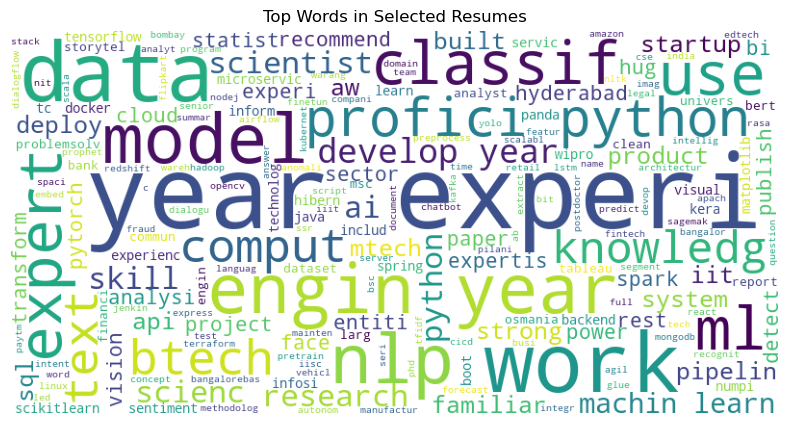

In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Word cloud for Selected candidates
selected_text = ' '.join(df[df['label'] == 'Selected']['cleaned_text'])
wc = WordCloud(width=800, height=400, background_color='white').generate(selected_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc)
plt.axis('off')
plt.title("Top Words in Selected Resumes")
plt.show()

## STEP 5 — Feature Extraction using TF-IDF

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=500)  # Use top 500 important words

X = tfidf.fit_transform(df['cleaned_text'])  # Feature matrix
y = df['label']                               # Labels (Selected/Rejected)

print("Feature matrix shape:", X.shape)  # (40, 500)
print("Top features:", tfidf.get_feature_names_out()[:20])

Feature matrix shape: (40, 365)
Top features: ['ab' 'account' 'acl' 'acquisit' 'ad' 'administr' 'adob' 'agenc' 'agent'
 'agil' 'ai' 'aiml' 'airflow' 'amazon' 'analysi' 'analyst' 'analyt'
 'anomali' 'answer' 'apach']


## STEP 6 — Split Data into Train and Test

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42      # For reproducibility
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 32
Test size: 8


## STEP 7 — Train a Machine Learning Model

In [16]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train the model
model = MultinomialNB()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00         4
    Selected       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



## STEP 8 — Confusion Matrix (Visual Evaluation)

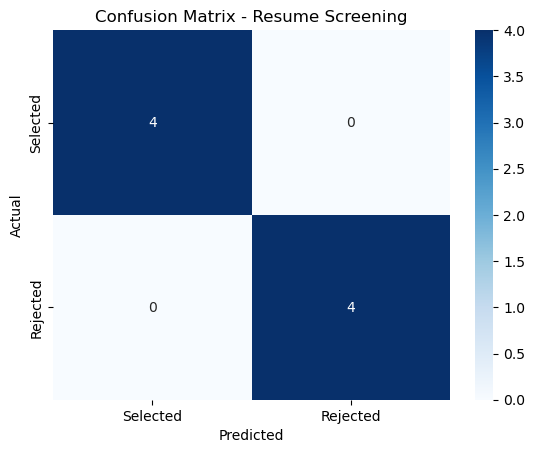

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=['Selected', 'Rejected'])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Selected', 'Rejected'],
            yticklabels=['Selected', 'Rejected'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Resume Screening")
plt.show()

## STEP 9 — Try on a New Resume (Prediction)

In [18]:
new_resume = """
Experienced data scientist with 4 years in NLP and machine learning.
Proficient in Python, scikit-learn, TensorFlow, and BERT.
Worked on text classification and sentiment analysis projects.
M.Tech in Computer Science from IIT.
"""

# Preprocess and predict
cleaned = preprocess_text(new_resume)
vectorized = tfidf.transform([cleaned])
prediction = model.predict(vectorized)

print("Prediction:", prediction[0])

Prediction: Selected


## STEP 10 — Try Other Models (Bonus)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr.predict(X_test)))

# Support Vector Machine
svm = LinearSVC()
svm.fit(X_train, y_train)
print("SVM Accuracy:", accuracy_score(y_test, svm.predict(X_test)))

Logistic Regression Accuracy: 1.0
SVM Accuracy: 1.0
